# Notebook para exploração e tratamento inicial dos dados

In [ ]:
# Importando as bibliotecas necessárias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importando os dados da Petrobras(PETR4.SA) entre 01/01/2018 e 01/01/2025

In [4]:
acao = "PETR4.SA"
data_inicio = "2018-01-01"
data_fim = "2025-01-01"

df = yf.download(acao, start=data_inicio, end=data_fim)

df.head()

C:\Users\romul\AppData\Roaming\Python\Python311\site-packages\yfinance\scrapers\history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2018-01-02,4.349908,4.349908,4.255288,4.255288,33461800
2018-01-03,4.389333,4.394590,4.302598,4.334138,55940900
2018-01-04,4.397219,4.457670,4.368307,4.410361,37064900
2018-01-05,4.423501,4.431386,4.355164,4.389333,26958200
2018-01-08,4.476068,4.476068,4.391960,4.399845,28400000


### Fazendo uma exploração dos dados

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1738 entries, 2018-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, PETR4.SA)   1738 non-null   float64
 1   (High, PETR4.SA)    1738 non-null   float64
 2   (Low, PETR4.SA)     1738 non-null   float64
 3   (Open, PETR4.SA)    1738 non-null   float64
 4   (Volume, PETR4.SA)  1738 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 81.5 KB


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
count,1738.000000,1738.000000,1738.000000,1738.000000,1.738000e+03
mean,12.882199,13.055147,12.707888,12.881640,6.432873e+07
std,8.537933,8.611428,8.461201,8.532524,3.582043e+07
min,3.198417,3.450551,3.073766,3.136091,0.000000e+00
25%,6.768086,6.891147,6.694632,6.793585,4.025255e+07
50%,8.390583,8.511938,8.277530,8.410549,5.633075e+07
75%,16.596231,16.922236,16.385129,16.560674,7.796510e+07
max,33.308643,33.448146,32.914749,33.111695,4.902304e+08


Com essa análise inicial, é possível perceber que todos os dados são numéricos. Também é possível constatar que não temos nenhum dado nulo no nosso DataFrame, logo não será necessário fazer o tratamento de nulls.

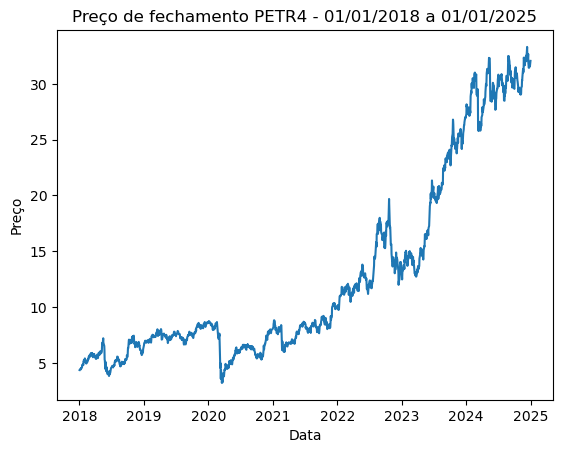

In [9]:
# Verificando os preços de fechamento
plt.plot(df['Close'])
plt.title('Preço de fechamento PETR4 - 01/01/2018 a 01/01/2025')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.show()

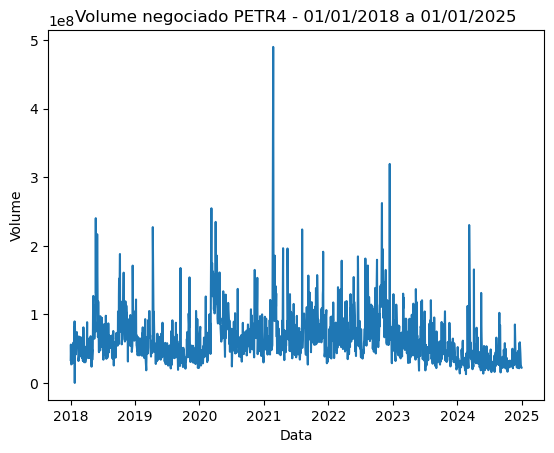

In [10]:
# Verificando o volume das ações negociadas por dia
plt.plot(df['Volume'])
plt.title('Volume negociado PETR4 - 01/01/2018 a 01/01/2025')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.show()

In [11]:
# Criando variáveis de médias móveis das ações para suavizar as variações diárias e conseguir entender as tendências.
df['MM30'] = df['Close'].rolling(window=30).mean()
df['MM60'] = df['Close'].rolling(window=60).mean()

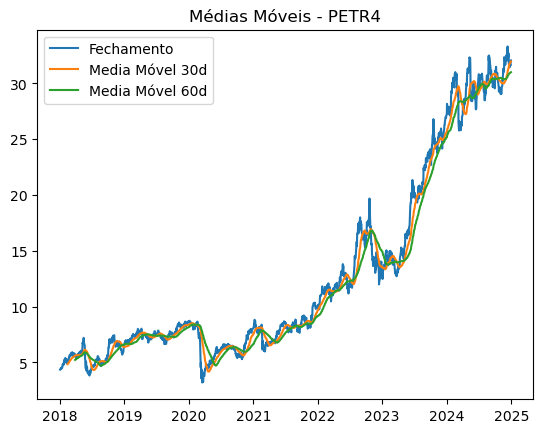

In [12]:
# Fazendo o plot da médias móveis de 30 e 60 dias, comparados com o preço de fechamento.

plt.plot(df['Close'], label='Fechamento')
plt.plot(df['MM30'], label='Media Móvel 30d')
plt.plot(df['MM60'], label='Media Móvel 60d')

plt.title('Médias Móveis - PETR4')

plt.legend()

plt.show()

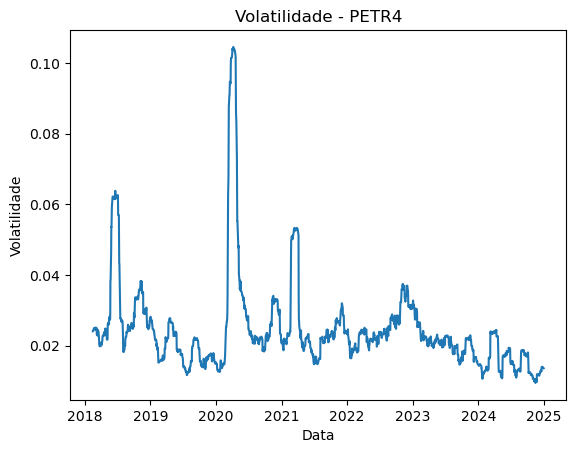

In [13]:
# Retorno diário
df['Retorno'] = df['Close'].pct_change()

# Volatilidade móvel
df['Volatilidade'] = df['Retorno'].rolling(window=30).std()

plt.plot(df['Volatilidade'])

plt.title('Volatilidade - PETR4')
plt.xlabel('Data')
plt.ylabel('Volatilidade')

plt.show()

Com essa análise exploratória, é possível ver que as ações da Petrobrás tem um comportamento razoavelmente estável. Tirando alguns picos de volatilidade, como o de 2020 por causa da Pandemia de Covid-19, é uma ação que tem uma volatilidade baixa. Também mantém um volume negociado diário baixo e vêm tendo um crescimento no seu preço de fechamento nos últimos anos.
Quando se olha para as médias móveis, é possível ver as tedências de crescimento suavizadas.
Também é possível fazer uma associação dos picos de volume negociado com os vales locais do valor de fechamento da ação, o que mostra que existe uma correlação entre o valor de fechamento e a quantidade de ações negociadas.